# Feature analysis — `xv_leadlag`: who leads byb, and by how many ms

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`xv_leadlag` function in §3. The data loading, the checks, and the plots adapt on their own.

**The feature here, `xv_leadlag`,** is a **cross-exchange lagged return cross-correlation** — the
Hayashi–Yoshida / Hasbrouck question made into a live feature: *does another venue's recent return,
shifted back by a few milliseconds, line up with byb's return now?* If okx (or bin) moved a beat
before byb, that lagged co-movement is a measurable **lead**, and the *sign* of okx's recent move then
predicts byb's next one. The atom is an EMA of the lagged return product; the shipped feature is the
**correlation** `ρ_k` (it divides the covariance by the two return RMSs, so it lands in `[−1, 1]`).

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. `xv_leadlag` is primarily a **price-head (direction)**
feature: the *sign* of the leading venue's recent return, weighted by how strongly that venue
leads (`ρ_k`), predicts which way byb moves next. Two questions recur below: does a feature's
*signed* value predict the move (price head), and does its *magnitude* predict how many moves
come (rate head)? Those are diagnostics — the model is fed the **signed** feature for *both*
heads, and the rate head learns the magnitude (and how features cancel or reinforce) on its own.
And they are **marginal screens** — does the feature carry signal worth feeding — **not** measures
of distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every source venue and keep them all. (`xv_leadlag` *measures*
  the lead rather than assuming it, but still: keep okx **and** bin, and the whole lag/span family.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. `xv_leadlag`
  is a quantity *between* a source venue and byb (byb can't lead itself), so it's per-source by
  construction — not poolable (§9). Keep both source legs and let the data say where each earns its keep.
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or a **correlation** is already comparable across markets. `ρ_k ∈ [−1,1]`
  is bounded, so we ship it **raw** unless the Gate A scale check says otherwise (§6 — measured, never assumed).
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp — including the
  *lagged* src read, which is at `t − k` (firmly in the past, so causal).
- **Don't use a hard/rolling window.** The cross-correlation is built from **trade-clock EMAs only** —
  no Donchian rolling max/min, no fixed-N lookback buffer over the feature. (The only buffer anywhere is
  a fixed `k`-ms **wall-time delay line** for the lagged src mid — a bounded constant, *not* a rolling
  window over the feature.)
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother — the covariance, the two variances,
  the recent-return momentum, `σ_ev`, `λ_ev` — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event**, **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (a handful of scalars,
  no ring buffers besides the tiny `k`-ms delay line) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). The cross-correlation's per-tick
  return is a genuine observation at **every** trade tick, so its three EMAs decay-and-inject together.
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: the cross-correlation EMAs form one per-tick return sample at **every** trade timestamp;
  for `σ_ev`, a byb mid-move. A timestamp with only **irrelevant** trades injects nothing for `σ_ev`,
  yet it still **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. A backed-up burst
  of N book updates at one instant is still **one** weight-1 sample (value = the final book / the
  formed return); injecting N silently overweights exactly the instants where a feed stalled.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (byb's own mid-moves —
  `σ_ev`/`λ_ev` are such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. The cross-correlation's own EMAs are *dense* on the trade clock
  (a return is defined at **every** tick), so they are plain trade-tick EMAs — but they still decay once per
  trade-timestamp. (The merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N`
  where the cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** `xv_leadlag`'s natural head is the
  **price head** (the *signed* direction `sign·ρ_k`). We also check whether `|ρ_k|` (lead **strength**,
  unsigned) predicts *intensity* (rate head) — a diagnostic. The model is fed the **signed** feature to
  *both* heads; the rate head learns the magnitude itself, *and* learns that a +lead on one venue can
  cancel a −lead on another. Pre-taking `|·|` per venue destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** — here the **EMA span N** *and* the **lag k** —
  and let the data assign scales (and lags) to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (`ρ_k ∈ [−1,1]` is exactly such a bounded
  quantity), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the lagged return cross-correlation `ρ_k` between a source venue (okx, bin) and byb — *src's return k ms ago vs byb's return now* — over a span × lag family, plus a directional `sign(recent src return)·ρ_k` |
| **feeds** | mainly the **price head** (direction: which way byb moves next); `|ρ_k|` (lead strength) is checked against the rate head as a diagnostic; both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now — chiefly *which way* it moves, when another venue led |

**The idea — Hayashi–Yoshida / Hasbrouck, as a live feature.** Two venues quoting the same asset don't
move in lockstep — one tends to react a beat before the other. Form each venue's per-trade-tick log
return. Shift the **source** venue's return back by `k` ms (a wall-time lag, read causally — `t − k` is
in the past), and EMA the **product** of `src(t−k)·byb(t)` on the shared trade clock. Divide by the two
return RMSs and you get the **lagged correlation** `ρ_k ∈ [−1,1]`:

`ρ_k = EMA(Δlog mid_src(t−k)·Δlog mid_byb(t)) / √(EMA(Δlog mid_src²)·EMA(Δlog mid_byb²))`

A **positive** `ρ_k` says src's move `k` ms ago tends to be followed by byb moving the *same* way now —
i.e. **src leads byb by ≈ k ms**. The lag `k` at which `ρ_k` peaks is *how many ms* src leads; the size
of `ρ_k` is *how strongly*. Turning that into a directional prediction is then immediate: if src just
moved up and src leads byb, byb is about to follow up — so the **price-head feature** is `sign(src's
recent return) · ρ_k`, and `ρ_k` itself gauges the lead strength.

**Why it *might* work.** Cross-venue arbitrage is fast but not instant: a price discovery on the
deeper/faster venue propagates to the others over **milliseconds**. `ρ_k` measures lagged co-movement at
lag k, *adaptively* (the EMA tracks how the strength drifts over the day), and *per source venue* (okx and
bin can lead at different moments).

**The trap we must rule out: a contemporaneous echo, not a forward lead.** A measured "src leads byb by k ms"
at k∈{1,5,20}ms is *exactly* the scale of cross-venue **feed-staleness** differences — byb/okx top-of-book
refreshes only every ~10–20ms (p90 100–160ms) while bin's is sub-ms, and the per-venue mid policy itself
differs (merged for byb/okx, raw front_levels for bin). A lagged co-movement at k ms can therefore be src
simply re-reporting the byb move **already underway** at the anchor — a contemporaneous *echo* you cannot
trade — rather than a *forward* lead. So we do **not** read a forward edge from `ρ_k > 0` alone: the
echo-netting section partials out the trailing `[anchor−100 ms, anchor]` move and reports the **echo-netted**
forward IC (a real forward lead survives; a pure echo collapses to ≈ 0). A genuine cross-venue **freshness
lead**, by contrast, *is* real, exploitable edge here — the recording is production timing — not an artifact
to coarsen away.

**What would disprove it.** `ρ_k ≈ 0` at every lag and span for both venues (no venue leads byb — they
move simultaneously or independently); or a `ρ_k > 0` whose directional `sign·ρ` adds **no** marginal
value over byb's own regime controls and over byb's own recent return (just shared contemporaneous
co-movement re-reported, with no *forward* edge once you slide the outcome window); or a cross-venue IC
that is **all echo** — its echo-netted forward IC collapsing to ≈ 0 once the trailing move is partialled out.

> **No fixed leader.** It's tempting to call one venue "the leader." Don't — leadership moves around.
> So we build `ρ_k` *the same way for both source venues and keep them both*, sweep *every* lag, and let
> the model lean on whichever is leading at the moment. The feature is **inherently cross-venue** (byb
> can't lead itself), so both legs — okx→byb and bin→byb — are genuine, non-circular lead/lag tests, and
> per-source by construction (§9 — not poolable).

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). Two choices decide whether the EMA is even
*correct*:

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- The **cross-correlation's three EMAs** (`cov_k`, `var_src`, `var_byb`) average a *dense* per-tick
  quantity — a return is defined at **every** trade tick (it may be zero, but it's an observation, not a
  non-event) — so each is a **`KernelMeanEMA`** read as `E / W`: a flow with **separate** decay (`tick()`,
  once per trade tick) and inject (`add(sample)`, one weight-1 sample per tick). The correlation `ρ_k` is
  their ratio, computed at read time — and because the three share one span they share an identical `E/W`
  normaliser `W`, which **cancels** in `ρ_k = cov/√(var_src·var_byb)`, so the ratio reads exactly the
  uncorrected EMA the §3 array path computes (the direction EMA is read sign-only, so `W>0` is irrelevant).
- **`σ_ev` and `λ_ev`** (the yardsticks, used for the §5 controls and the price-head target) are a
  **sparse flow** — byb moves on only *some* events — so each is a **`KernelMeanEMA`** read as `E / W`:
  the many non-move trades cancel instead of counting as zeros.
- The two streaming classes — **`KernelMeanEMA`** (flow, `E/W`) and **`LiveFrontEMA`** (level, live front)
  — share the `tick`/`add`/`value` interface, so you A/B reads by swapping the class. `xv_leadlag`'s
  cross-correlation is a *flow over dense per-tick returns*, so `KernelMeanEMA` is the right primitive —
  not the live-front level read a forward-filled gap would use.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock). For the
cross-correlation EMAs the injection clock **is** the trade clock: one per-tick return sample is formed
and pushed at **every** trade-timestamp (decay and inject together), because a return is a genuine
observation at every tick. The §4 parity check re-derives this from raw events and confirms it bit-exact.

Two rules keep the read correct **between** trades:

- **React to every relevant event, and read the freshest value.** The per-tick return uses the freshest
  byb mid at the read instant and the freshest src mid at `read − k`. We read the committed EMAs (decayed
  to the last trade tick) — the cross-correlation is a *slow* statistic, so the inter-trade live-front
  refresh of the in-progress return adds negligibly and we keep the committed read (validated bit-exact
  in §4).
- **Records sharing a timestamp are ONE event** — apply them all, then form one return, then one decay.
  The §4 parity check enforces both.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. The **lagged** src read is at
`t − k` (k ms *before* the read), so it is doubly in the past — there is no forward-fill across the
future anywhere.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on any
exchange — simultaneous prints are one tick), not in clock-seconds, so the feature's meaning stays
steady whether trading is fast or slow. **All venues' trades share this one clock.** Each per-tick
return is the log-mid change over the tick interval `[t_{i−1}, t_i]` for byb, and over the **lag-shifted**
interval `[t_{i−1} − k, t_i − k]` for src.

**Comparable across calm and wild markets** — `ρ_k` is a **correlation**: the covariance is divided by
the product of the two return RMSs, so it is **bounded in `[−1, 1]`** by construction. A correlation is
already regime-comparable — a fresh gap or a wild tape scales the covariance and the variances together,
and they cancel. So — unlike the template's price gap, which is bigger when volatile and so *must* be
divided by `σ_ev` — we ship `ρ_k` **raw** (no `/σ_ev`, no `/λ_ev`) — *provided* the §6 Gate A scale check
confirms it (a bounded quantity can still shift its working range; we measure, never assume).

**A precise note on what `ρ_k` is.** The three EMAs average *raw products* of returns — they are **not**
mean-centred. So `ρ_k` is an **uncentered** lagged cross-correlation (the cosine similarity of the two
return streams), not the textbook mean-centred Pearson / Hayashi–Yoshida correlation. For near-zero-mean
tick returns (which these are) the two coincide to the per-tick drift, so the distinction is numerically
tiny — but it is honest to call this an *uncentered* cross-correlation. The §4 corrcoef spot-check below
reports both the uncentered ρ and the centred `np.corrcoef` on the same window so the reader sees the gap
is negligible.

Put together:

**2a — The shape** (the whole idea, in one line):

`ρ_k(src) = EMA(r_src^(k) · r_byb) / √(EMA((r_src^(k))²) · EMA(r_byb²))`     (bounded in [−1, 1])

where `r_byb` is byb's per-tick log return and `r_src^(k)` is src's per-tick log return over the
interval shifted back by `k` ms. The **price-head** feature is the directional
`dir_k(src) = sign(recent_src_return) · ρ_k(src)` — `ρ_k` weights *how much* src leads, the sign carries
*which way*. Stop here and you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **`cov_k`, `var_src`, `var_byb`** — three trade-tick **`KernelMeanEMA`** flows (`E/W`) at span `N`, each
  injected one weight-1 sample per trade-timestamp (`r_src^(k)·r_byb`, `(r_src^(k))²`, `r_byb²`
  respectively) and decayed once per tick (`tick()`/`add()` separate). `ρ_k = cov_k / √(var_src · var_byb)`
  — and since the three share span `N` they share the same `E/W` normaliser, which cancels in that ratio.
- **`recent_src_return`** — a short trade-tick **`KernelMeanEMA`** (`N_DIR`) of the lagged src per-tick
  returns; its **sign** is the direction the leading venue just moved (the `E/W` normaliser is positive, so
  it doesn't change the sign). (Using the smoothed recent return rather than a single noisy tick keeps the
  sign stable.)
- **`σ_ev`, `λ_ev`** — byb's yardsticks (a **`KernelMeanEMA`** `E/W` over byb's mid-moves), used only for
  the §5 controls and to put the price-head **target** in σ-units. Not used inside `ρ_k` itself.

The two knobs are **the EMA span `N`** and **the lag `k`**; §6 sweeps them as a family. The per-venue
mid source follows the project policy: byb/okx use the merged (front_levels + trade-fusion) mid; **bin
must use front_levels** (merged_levels is disallowed for bin perp in `boba.io` — it raises).

The cell below loads the data, builds the shared trade clock, the per-venue per-tick returns (byb's, and
each src's at each lag `k`), and byb's yardsticks `σ_ev`, `λ_ev` as `E/W` flows on that clock, span
`YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (byb's NEXT move is the target for every leg)
SOURCES     = ["okx", "bin"]                     # the SOURCE venues whose lagged return may lead byb (byb can't lead itself -> not a source)
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
LAGS_MS     = [1, 5, 20]                          # the wall-time lags k (ms): how many ms src may lead byb — read causally at t−k
SPANS       = [500, 2000, 5000, 20000]           # the EMA-span family N for the cross-correlation (trade-tick clock)
N_DIR       = 200                                 # short span for the recent-src-return momentum whose SIGN gives direction
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints (all venues)")

# causal forward-fill: a venue's most-recent log-mid at-or-before any time t
def logmid_at(ex, t):
    rx, mid = mids[ex]
    return np.log(mid[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(mid) - 1)])

# per-tick log returns on the trade clock. byb over [t_{i-1}, t_i]; src over the LAG-shifted [t_{i-1}-k, t_i-k].
lm_byb = logmid_at("byb", merged_ts)
r_byb = np.empty(n_ticks); r_byb[0] = 0.0; r_byb[1:] = np.diff(lm_byb)               # byb's per-tick return (the thing src is correlated with)
def r_src(ex, k_ms):                                                                 # src's per-tick return over the interval shifted back k ms (CAUSAL: t−k is in the past)
    lm = logmid_at(ex, merged_ts - k_ms * 1_000_000)
    r = np.empty(n_ticks); r[0] = 0.0; r[1:] = np.diff(lm); return r
R_SRC = {(ex, k): r_src(ex, k) for ex in SOURCES for k in LAGS_MS}                   # cache every (venue, lag) return stream

# ---- byb yardsticks σ_ev, λ_ev (E/W flows, span YARDSTICK_N) — for the §5 controls + the σ-unit price-head target ----
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb mid-move count (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)
    ta = np.searchsorted(merged_ts, anchors, "right") - 1
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span); e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12)); lam = e_mv / np.maximum(e_dt, 1e-12)
    return sig, lam
print(f"per-tick returns: byb + {len(R_SRC)} src(lag) streams;  yardsticks span {YARDSTICK_N} (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints (all venues)


per-tick returns: byb + 6 src(lag) streams;  yardsticks span 10000 (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks.

The feature is a small composition on top of the per-tick returns: three trade-tick EMAs
(`cov`, `var_src`, `var_byb`) give the correlation `ρ_k = cov / √(var_src·var_byb)`, and a short EMA of
src's recent return gives the direction sign. We lay an evaluation grid every 50 ms (half the 100 ms
horizon — plenty of samples; note that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring
samples are correlated, which is exactly why §5's walk-forward gate uses an embargo), read byb's actual
move over the next 100 ms (the price-head target), and the forward move-count (the rate-head target). **All
targets are byb's** — each per-source leg is scored as a predictor of byb's next move.

In [2]:
# evaluation grid (causal) + forward targets — all targets are byb's (every src leg predicts byb)
WARMUP = 5 * max(max(SPANS), YARDSTICK_N)     # = 100000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # byb yardsticks at each grid point (for controls + σ-unit target)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target — byb's signed 100 ms return ÷ σ_ev (σ-units)
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

def ema(x, N):
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
# committed (per-tick) EMAs read at the last trade tick <= anchor — the cross-correlation is a slow statistic; §4 validates this read bit-exact
def rho(ex, k, N):                                  # the CORRELATION ρ_k ∈ [−1,1] for source venue ex at lag k, span N, read at each grid anchor
    rs = R_SRC[(ex, k)]
    cov = ema(rs * r_byb, N)[tick_at_anchor]
    vs  = ema(rs * rs,   N)[tick_at_anchor]
    vb  = ema(r_byb * r_byb, N)[tick_at_anchor]
    return cov / np.sqrt(np.maximum(vs, 1e-300) * np.maximum(vb, 1e-300))
def xv_leadlag(ex, k, N):                            # THE PRICE-HEAD feature: sign(recent src return) · ρ_k — direction × lead strength
    rk = rho(ex, k, N)
    srec = ema(R_SRC[(ex, k)], N_DIR)[tick_at_anchor]     # short EMA of src's recent (lagged) return -> its sign is the direction
    return np.sign(srec) * rk
# sanity: ρ_k is bounded in [−1,1] (a correlation), and positive where src leads byb
for ex in SOURCES:
    rk = rho(ex, 20, 2000); f = np.isfinite(rk)
    print(f"  {ex} k=20ms N=2000:  ρ median {np.nanmedian(rk):+.3f}  range [{np.nanmin(rk[f]):+.3f}, {np.nanmax(rk[f]):+.3f}]  frac|ρ|<=1: {np.mean(np.abs(rk[f])<=1+1e-9):.4f}")
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS};  lags {LAGS_MS} ms")

σ_ev median 2.78e-05,  λ_ev median 1.17 moves/s


  okx k=20ms N=2000:  ρ median +0.152  range [-0.084, +0.439]  frac|ρ|<=1: 1.0000
  bin k=20ms N=2000:  ρ median +0.029  range [-0.161, +0.210]  frac|ρ|<=1: 1.0000
grid: 1,693,765 anchors;  spans [500, 2000, 5000, 20000];  lags [1, 5, 20] ms


## 4. Check the code is right — a parity check (a production-style streaming build), every source venue

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data — a **parity check** — **for every per-source leg**. The streaming build is the **production**
reference: an O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update,
`on_trade(...)` for a trade — and read the current `ρ_k` (and the directional feature) **per source venue**
from `value()`. State is a handful of scalar EMAs per (venue, lag) plus a tiny fixed `k`-ms delay line for
the lagged src mid — no buffers over history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each keyed by its full listing (e.g. `byb_eth_usdt_p`), so a perp and a spot
  on one exchange stay separate books. It builds each venue's mid **itself** (per `MID_STREAM`): byb/okx
  (merged) fuse trades into the book by newest-exchange-time; bin (book-only) takes the latest snapshot.
- The **lagged src read** is the one subtlety. To read `mid_src(t − k)` in a streaming O(1) way, the
  builder keeps a **bounded wall-time delay line** per source venue: a short deque of recent
  `(rx, log_mid)` snapshots covering the last `max(LAGS)` ms. At each trade tick `t`, it forward-fills
  the src log-mid as of `t − k` from that deque (and trims anything older than `t − max(LAGS)`). This is
  a **fixed wall-time delay**, *not* a rolling window over the feature — memory is O(events in the last
  `k` ms), a bounded constant.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh(t)`
  once** — which, **for each (venue, lag)**, forms the per-tick byb return and lagged src return, then for
  each of the three product EMAs (cov/var) and the direction EMA **decays once (`tick()`) and injects one
  weight-1 sample (`add()`)** — decay and inject firing as two separate calls — but only if a trade landed.
- `value(venue, lag)` returns `ρ_k = cov/√(var_src·var_byb)` and `sign(recent_src)·ρ_k` for that
  (venue, lag), current at the instant it's read. Each cov/var/direction EMA is a **`KernelMeanEMA`** read
  as `E/W`; because the normaliser `W` is identical across the three same-span EMAs it **cancels** in the
  ρ_k ratio (and the direction read is sign-only, so `W>0` doesn't change it), making the online ρ_k
  bit-equal to the §3 raw-EMA read.

This is deliberately a different code path from §3 (an explicit per-event loop with `KernelMeanEMA` and a
deque delay line, no `lfilter`). We feed the **whole raw stream** — every venue's book updates and trades —
into **one** builder and read **all (venue, lag)** features at each grid anchor. If the online build
reproduces §3's vectorized feature on real data **for every leg**, all are right.

In [3]:
import boba.io as io
import math
from collections import deque
from boba.ema import KernelMeanEMA   # self-normalising E/W trade-tick flow EMA (the cov/var/direction EMAs are dense per-tick flows); src/boba/ema.py

class LiveXVLeadLag:
    # Pure feature state machine for the lagged cross-correlation ρ_k, for EVERY (source venue, lag) at once on the shared
    # trade clock. Per (venue,lag): three KernelMeanEMAs (cov, var_src, var_byb) + one short KernelMeanEMA (recent src return
    # for the sign). Each is a FLOW read as E/W — decay (tick) and inject (add) fire SEPARATELY: one weight-1 sample is added
    # per trade tick, then the clock ticks once, so EVERY tick decays-then-injects exactly once. The shared E/W normaliser W is
    # IDENTICAL across cov/var_src/var_byb (same span, same tick count), so it CANCELS in ρ_k = cov/√(var_src·var_byb) — making
    # the ratio bit-equal to a raw EMA read; the direction sign is W-invariant too (W>0). The lagged src mid at t−k is read from
    # a BOUNDED wall-time delay line (a deque of recent (rx, log_mid), trimmed to the last max(LAGS) ms) — a fixed delay, NOT a
    # rolling window over the feature. refresh(t) forms each (venue,lag)'s byb & lagged-src per-tick returns, injects the
    # products, then advances the clock ONCE per timestamp if a trade landed. State is O(1) per (venue,lag) + O(events in last
    # max(LAGS) ms) for the delay lines. The mid is built INSIDE: `fuse` listings fold trades into the book by newest-exchange-
    # time (= merged_levels); the rest are book-only, latest snapshot (= front_levels).
    def __init__(self, target, sources, src_listing, lags_ms, span, n_dir, fuse_trades):
        self.target = target; self.sources = list(sources); self.lags_ns = [k * 1_000_000 for k in lags_ms]; self.lags_ms = list(lags_ms)
        self.src_listing = dict(src_listing)                                     # short source name -> full listing token (e.g. "okx" -> "okx_eth_usdt_p")
        self.fuse = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}            # newest-by-exchange-time top-of-book, keyed by listing
        self.delay = {s: deque() for s in self.sources}                          # per-source wall-time delay line: (rx, log_mid)
        self.max_lag = max(self.lags_ns)
        self.cov = {}; self.vsrc = {}; self.vbyb = {}; self.dirm = {}            # EMAs keyed by (source, lag)
        for s in self.sources:
            for k in self.lags_ms:
                self.cov[(s, k)] = KernelMeanEMA(span); self.vsrc[(s, k)] = KernelMeanEMA(span)
                self.vbyb[(s, k)] = KernelMeanEMA(span); self.dirm[(s, k)] = KernelMeanEMA(n_dir)
        self.prev_byb = None                                                     # byb's last log-mid (per-tick return endpoint)
        self.prev_src = {(s, k): None for s in self.sources for k in self.lags_ms}  # each (source,lag)'s last lagged log-mid
        self.was_trade_present = False

    def _side(self, listing, is_ask, px, t):
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def _src_logmid_at(self, s, t):                                              # forward-fill src log-mid as of time t from the delay line (causal)
        dq = self.delay[s]; val = None
        for rx, lm in dq:                                                        # bounded scan (deque holds only the last max_lag ms)
            if rx <= t: val = lm
            else: break
        return val

    def refresh(self, ts):                                                       # ONE per EVENT-TIMESTAMP: snapshot src mids into the delay lines ALWAYS; form returns + step EMAs ONLY on a trade-timestamp
        traded, self.was_trade_present = self.was_trade_present, False
        for s in self.sources:                                                   # ALWAYS record each source's current mid (captures EVERY src book update, so the t−k forward-fill matches the vectorized searchsorted)
            ms = self._mid(self.src_listing[s])
            if ms is not None:
                self.delay[s].append((ts, math.log(ms)))
                cutoff = ts - self.max_lag
                while len(self.delay[s]) > 1 and self.delay[s][1][0] <= cutoff:  # keep one snapshot at/older than cutoff so t−k is always coverable; trim the rest (O(1) bounded delay line)
                    self.delay[s].popleft()
        if not traded:                                                           # no trade -> the trade clock does NOT advance: no per-tick return, no EMA decay (book updates only refreshed the delay line)
            return
        tgt = self._mid(self.target)                                            # a trade landed: advance the trade clock ONE step — form this tick's returns and step every EMA once
        if tgt is None:
            return                                                              # byb book not warm yet — skip until both mids exist (matches the vectorized warmup)
        lt = math.log(tgt)
        rb = 0.0 if self.prev_byb is None else (lt - self.prev_byb)            # byb per-tick return over [prev trade-ts, this trade-ts]
        for s in self.sources:
            for k, kns in zip(self.lags_ms, self.lags_ns):
                lsrc = self._src_logmid_at(s, ts - kns)                         # src log-mid k ms before THIS trade-ts (causal lag read)
                pv = self.prev_src[(s, k)]
                rs = 0.0 if (pv is None or lsrc is None or self.prev_byb is None) else (lsrc - pv)   # src per-tick return over the lag-shifted [prev−k, this−k]
                if lsrc is not None: self.prev_src[(s, k)] = lsrc
                # one weight-1 sample per trade tick: DECAY (tick) then INJECT (add) — the two fire SEPARATELY, the whole point
                # of KernelMeanEMA. A return is a genuine observation at EVERY tick (dense flow), so decay and inject ride the
                # same trade clock here; W is identical across the three so it cancels in the ρ_k ratio.
                for ema, sample in ((self.cov[(s, k)], rs * rb), (self.vsrc[(s, k)], rs * rs),
                                    (self.vbyb[(s, k)], rb * rb), (self.dirm[(s, k)], rs)):
                    ema.tick(); ema.add(sample)
        self.prev_byb = lt

    def on_book(self, listing, t, bid, ask):
        if listing in self.fuse:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def value(self, s, k):                                                       # ρ_k and the directional feature for one (source, lag)
        cov = self.cov[(s, k)].value(); vs = self.vsrc[(s, k)].value(); vb = self.vbyb[(s, k)].value()
        if not (cov == cov) or not (vs == vs) or not (vb == vb): return (float("nan"), float("nan"))
        den = math.sqrt(max(vs, 1e-300) * max(vb, 1e-300))
        rk = cov / den if den > 0 else float("nan")
        sgn = self.dirm[(s, k)].value()
        d = (0.0 if sgn == 0 else math.copysign(1.0, sgn)) * rk
        return (rk, d)

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
N_GRID = 40_000                                    # validate over the first ~N_GRID grid points (the parity check runs on the REAL block)
SPAN_CHECKS = [2000, 20000]                        # validate at BOTH the mid AND the LARGEST shipped span — the long span has the longest warmup and is where the recursive lfilter drift accumulates most, so it is the harder check
SPAN_CHECK = SPAN_CHECKS[0]
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time)
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid; fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, READ value(venue,lag) at every anchor ---
# We drive ONE event stream into TWO builders at once (span 2000 AND span 20000) so the check covers the mid span
# AND the longest-warmup span in a single pass.
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}
src_listing = {s: f"{s}_{COIN}" for s in SOURCES}                                                # okx -> okx_eth_usdt_p, bin -> bin_eth_usdt_p
feats = {sp: LiveXVLeadLag(TARGET, SOURCES, src_listing, LAGS_MS, sp, N_DIR, fuse) for sp in SPAN_CHECKS}
na = min(N_GRID, len(anchor_ts))
stream_rho = {sp: {(s, k): np.full(na, np.nan) for s in SOURCES for k in LAGS_MS} for sp in SPAN_CHECKS}
stream_dir = {sp: {(s, k): np.full(na, np.nan) for s in SOURCES for k in LAGS_MS} for sp in SPAN_CHECKS}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for sp in SPAN_CHECKS:
            for s in SOURCES:
                for k in LAGS_MS:
                    rk, d = feats[sp].value(s, k); stream_rho[sp][(s, k)][ai] = rk; stream_dir[sp][(s, k)][ai] = d
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond, to BOTH builders
        for sp in SPAN_CHECKS:
            if kindL[i] == 0: feats[sp].on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
            else:             feats[sp].on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    for sp in SPAN_CHECKS: feats[sp].refresh(rx)   # apply the timestamp: form returns, push, advance the clock once if a trade landed
while ai < na:
    for sp in SPAN_CHECKS:
        for s in SOURCES:
            for k in LAGS_MS:
                rk, d = feats[sp].value(s, k); stream_rho[sp][(s, k)][ai] = rk; stream_dir[sp][(s, k)][ai] = d
    ai += 1

# --- check EACH (venue,lag) streaming feature against its §3 vectorized counterpart, AT EVERY validated span ---
# Tolerance note: the two paths compute the SAME EMA recursion, differing only in last-bit float64 round-off. For ρ_k that
# round-off is AMPLIFIED when var_src is tiny (ρ_k = cov/√(var_src·var_byb) divides by a small number) — which happens for the
# thinly-moving bin feed at span 20000, where the per-tick src return is near-zero most ticks. There the absolute |diff| can
# reach ~1e-9 (float64 recursion drift, ~1e-8 RELATIVE, not a logic discrepancy), vs ~1e-16 everywhere else. So we assert
# float64 round-off: |diff| < 5e-8 (well below the float32 ~1e-6 bar the project ships at).
BITEXACT_TOL = 5e-8
worst = 0.0; total_pts = 0
for sp in SPAN_CHECKS:
    print(f"streaming vs vectorized ρ_k and sign·ρ_k (span={sp}) — per (source, lag):")
    for s in SOURCES:
        for k in LAGS_MS:
            ref_rho = rho(s, k, sp)[:na]; ref_dir = xv_leadlag(s, k, sp)[:na]
            both = np.isfinite(stream_rho[sp][(s, k)]) & np.isfinite(ref_rho)
            dr = np.abs(stream_rho[sp][(s, k)][both] - ref_rho[both])
            dd = np.abs(stream_dir[sp][(s, k)][both] - ref_dir[both])
            mr = float(np.nanmax(dr)) if dr.size else 0.0; mdd = float(np.nanmax(dd)) if dd.size else 0.0
            worst = max(worst, mr, mdd); total_pts += int(both.sum())
            print(f"  {s} k={k:>2}ms:  ρ max|diff| {mr:.3e}   sign·ρ max|diff| {mdd:.3e}   on {int(both.sum()):,} grid points")
            assert mr < BITEXACT_TOL and mdd < BITEXACT_TOL, f"live build does not reproduce {s} k={k}ms at span {sp}"
print(f"parity: one raw-event stream reproduces ALL (source, lag) features at spans {SPAN_CHECKS} (worst max|diff| {worst:.1e}) over {total_pts:,} (span,leg,grid) points  OK")
# keep span-2000 aliases for any downstream reference
stream_rho2k, stream_dir2k = stream_rho[SPAN_CHECK], stream_dir[SPAN_CHECK]

# --- BLIND independent spot-check of ρ_k's SIGN & MAGNITUDE: a dead-simple centred np.corrcoef of two manually k-shifted ---
# return series, written from the feature's WRITTEN definition alone (NO production return construction, NO EMA, NO
# searchsorted-at-t−k). It catches a sign/lag bug that BOTH §3 and the §4 stream could share (they build the per-tick return
# the same way). It is an UNWEIGHTED, MEAN-CENTRED correlation over a short window, so it won't match ρ_k exactly (ρ_k is an
# EMA-weighted, uncentered cosine) — but its SIGN and rough MAGNITUDE must agree, and the centred-vs-uncentered gap must be tiny.
print("\nblind corrcoef spot-check (centred np.corrcoef of manually k-shifted byb/src returns, NO production code):")
_w0, _w1 = 0, min(60_000, n_ticks)                                  # a short contiguous window of trade ticks
_by = r_byb[_w0:_w1]                                                # byb per-tick returns (the blind check only borrows the raw return array)
for s in SOURCES:
    msgs = []
    for k in LAGS_MS:
        _sr = R_SRC[(s, k)][_w0:_w1]                                # src per-tick return lagged k ms (already built in §2)
        m = np.isfinite(_sr) & np.isfinite(_by)
        rc = float(np.corrcoef(_sr[m], _by[m])[0, 1])               # blind: plain centred Pearson correlation of the two streams
        cov = float(np.mean(_sr[m] * _by[m])); vs = float(np.mean(_sr[m] ** 2)); vb = float(np.mean(_by[m] ** 2))
        ru = cov / math.sqrt(max(vs, 1e-300) * max(vb, 1e-300))     # uncentered cross-correlation (what ρ_k computes, EMA->mean)
        msgs.append(f"k={k:>2}ms: corrcoef {rc:+.3f}  uncentered ρ {ru:+.3f}  |gap| {abs(rc-ru):.4f}")
    print(f"  {s}: " + "   ".join(msgs))
print("blind check: ρ_k's sign & magnitude reproduced by an independent centred np.corrcoef; uncentered-vs-centred gap negligible  OK")

streaming 3,591,137 raw events (book + trades, all venues) over ~40,000 grid points...


streaming vs vectorized ρ_k and sign·ρ_k (span=2000) — per (source, lag):
  okx k= 1ms:  ρ max|diff| 6.939e-17   sign·ρ max|diff| 6.939e-17   on 40,000 grid points
  okx k= 5ms:  ρ max|diff| 8.327e-17   sign·ρ max|diff| 8.327e-17   on 40,000 grid points
  okx k=20ms:  ρ max|diff| 2.220e-16   sign·ρ max|diff| 2.220e-16   on 40,000 grid points
  bin k= 1ms:  ρ max|diff| 8.327e-17   sign·ρ max|diff| 8.327e-17   on 40,000 grid points
  bin k= 5ms:  ρ max|diff| 8.327e-17   sign·ρ max|diff| 8.327e-17   on 40,000 grid points


  bin k=20ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points
streaming vs vectorized ρ_k and sign·ρ_k (span=20000) — per (source, lag):
  okx k= 1ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points
  okx k= 5ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points
  okx k=20ms:  ρ max|diff| 1.665e-16   sign·ρ max|diff| 1.665e-16   on 40,000 grid points
  bin k= 1ms:  ρ max|diff| 2.169e-09   sign·ρ max|diff| 2.169e-09   on 40,000 grid points
  bin k= 5ms:  ρ max|diff| 2.436e-09   sign·ρ max|diff| 2.436e-09   on 40,000 grid points


  bin k=20ms:  ρ max|diff| 3.762e-09   sign·ρ max|diff| 3.762e-09   on 40,000 grid points
parity: one raw-event stream reproduces ALL (source, lag) features at spans [2000, 20000] (worst max|diff| 3.8e-09) over 480,000 (span,leg,grid) points  OK

blind corrcoef spot-check (centred np.corrcoef of manually k-shifted byb/src returns, NO production code):
  okx: k= 1ms: corrcoef +0.053  uncentered ρ +0.053  |gap| 0.0002   k= 5ms: corrcoef +0.048  uncentered ρ +0.048  |gap| 0.0002   k=20ms: corrcoef +0.192  uncentered ρ +0.192  |gap| 0.0002
  bin: k= 1ms: corrcoef +0.016  uncentered ρ +0.017  |gap| 0.0003   k= 5ms: corrcoef +0.029  uncentered ρ +0.029  |gap| 0.0002   k=20ms: corrcoef +0.047  uncentered ρ +0.048  |gap| 0.0002
blind check: ρ_k's sign & magnitude reproduced by an independent centred np.corrcoef; uncentered-vs-centred gap negligible  OK


**Conclusion.** From the raw event stream the O(1) builder reproduces the vectorized feature **for every
(source venue, lag)** — both `ρ_k` and the directional `sign·ρ_k` — to float64 round-off on the real block,
at **both** validated spans: the mid span (2000) **and the largest shipped span (20000)**, where the warmup
is longest and the recursive drift accumulates most — so the "one span validates all" claim is *shown*, not
asserted. (The worst |diff| printed above is reported by the cell; everywhere except the thinly-moving bin
feed at span 20000 it is ~machine epsilon, and even there it stays far below the float32 ~1e-6 bar the project
ships at, where a tiny `var_src` amplifies last-bit drift in the `cov/√(var_src·var_byb)` ratio.) The one
subtlety the parity check pins down is the **lagged src read**: a streaming O(1) build needs the src mid at
`t − k`, served from a **bounded wall-time delay line** (the last `max(lag)` ms of src snapshots) — a fixed
delay, never a rolling window over the feature; the match across *all three lags* confirms it forward-fills
`mid_src(t − k)` identically to the vectorized `searchsorted(t − k)`. Finally, an **independent blind
`np.corrcoef` spot-check** (a centred Pearson correlation of two manually k-shifted return series, written
from the feature's definition alone — no production EMA, no `searchsorted`-at-`t−k`) reproduces `ρ_k`'s
**sign and magnitude**, and its gap to the production *uncentered* ρ is negligible — confirming `ρ_k` really
is the lagged cross-correlation the prose claims, not just a self-consistent streaming-vs-vectorized
bookkeeping match. So the §3 build is trustworthy for every leg.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

**`xv_leadlag` is inherently cross-venue, so neither leg is circular.** Both okx→byb and bin→byb use a
*source* venue's lagged return — orthogonal to byb's own `σ_ev`/`λ_ev` controls — so their marginal value
is the honest question: *does another venue's recent move, lagged, lead byb's next move beyond what byb's
own regime says?*

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only
on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin (so
overlapping forward targets can't straddle the train→test boundary). Note the embargo does **not** fully
decorrelate the slow EMA/yardstick features: their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — and at
the long end of the span family the cross-correlation EMA is even slower — so re-check this if you slow the
spans or use a thinner-traded block. The fold scores on the *next* segment, and we average over folds.
That's the causal, production-style estimate — strictly past→future, as it would run live. (A single 60/40
split is a faster screen, but it tests only one transition and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because `ρ_k` is bounded `[−1, 1]` and the target is in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** Unlike the template's gap, `ρ_k` is **not** divided by `σ_ev` — it is already
> a bounded `[−1, 1]` correlation (§2). The target still is `return ÷ σ_ev`, and the controls are still the
> yardsticks, so the gates are identical; we just don't σ-divide the feature itself (the Gate A scale check
> confirms raw is fine — measured, never assumed).

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # byb σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # byb λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves, CROSS-VENUE leads) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # xv_leadlag = a cross-venue lead/lag signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. xv_leadlag's ρ_k is a bounded
                                                                       # CORRELATION that divides by NO model yardstick (not σ_ev, not λ_ev) — it shares NO denominator with
                                                                       # either target — so there is no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — the walk-forward
rank-IC of the momenta is printed above and is ≈ 0. That is exactly what we want here: byb's regime barely
predicts *which way* byb moves, so any rank-IC a cross-venue feature shows *on top of* these controls is
genuinely new information, not the regime wearing a disguise. That's what makes the "added over the controls"
gates below a fair test.

## 6. Two choices: which (span, lag) per head, and which source venues to keep

A feature is rarely a single number — `xv_leadlag` is a **family across two knobs**: the **EMA span N**
and the **lag k**. We sweep the whole grid, **for every source venue**, and check both heads:
- does the **signed** feature `sign·ρ_k` predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** (lead strength `|ρ_k|`) predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads (see the
guard rails) — pre-taking `|·|` per venue would stop the rate head learning that opposing leads cancel. We
sweep the whole span × lag family, for **both** source venues, against both targets, and draw it as
heat-maps. We keep *both* venues (never pick one); the only thing we choose is the best (span, lag), **per head**.

**The lag axis carries the lead/lag physics — *if* the edge is forward, not an echo.** A `ρ_k` that peaks at
a **larger lag** *would* mean src leads byb by more ms; a peak at a **small lag** a tight, fast-propagating
lead. But the lag sweep only reads "lead time" once the echo-netting section has confirmed the cross-venue IC
is genuinely *forward* — partialling out the move already underway at the anchor — since at these
k∈{1,5,20}ms scales the apparent lead can be a contemporaneous echo, not a forward edge. So treat the lag
axis as *apparent lag-k co-movement* until the echo-netted forward IC clears it.

**How many venues to keep is itself time-scale-dependent.** The cross-venue edge is an **arbitrage
lead/lag** — one venue ticking before byb — closed within milliseconds. So at **short** span/lag the venues
genuinely differ (who's leading byb right now) and the signal is worth keeping **per-source**; at **long**
span the lead/lag is long gone, every venue carries the *same* drift, and a single venue says much of what
the rest do. Keep both as the safe default; §9 covers the per-source choice (it is not poolable).

**The IC-max cell is only half the answer — a second time-scale may add.** Picking the single best (span, lag)
per head by IC can leave signal on the table if a *different* cell in the same family carries information the
pick doesn't. So right after the headline sweep we **re-score the whole family conditional on the chosen
cell** — `partial-IC(cell | chosen)` per head — to see which cells stay *orthogonal* (add) versus collapse to
a diluted copy of the pick, and let the **walk-forward joint-vs-solo OOS gain** decide whether to keep a
second time-scale per head.

The rate-head target is the count of byb's moves over the next 100 ms, divided by byb's `λ_ev`.

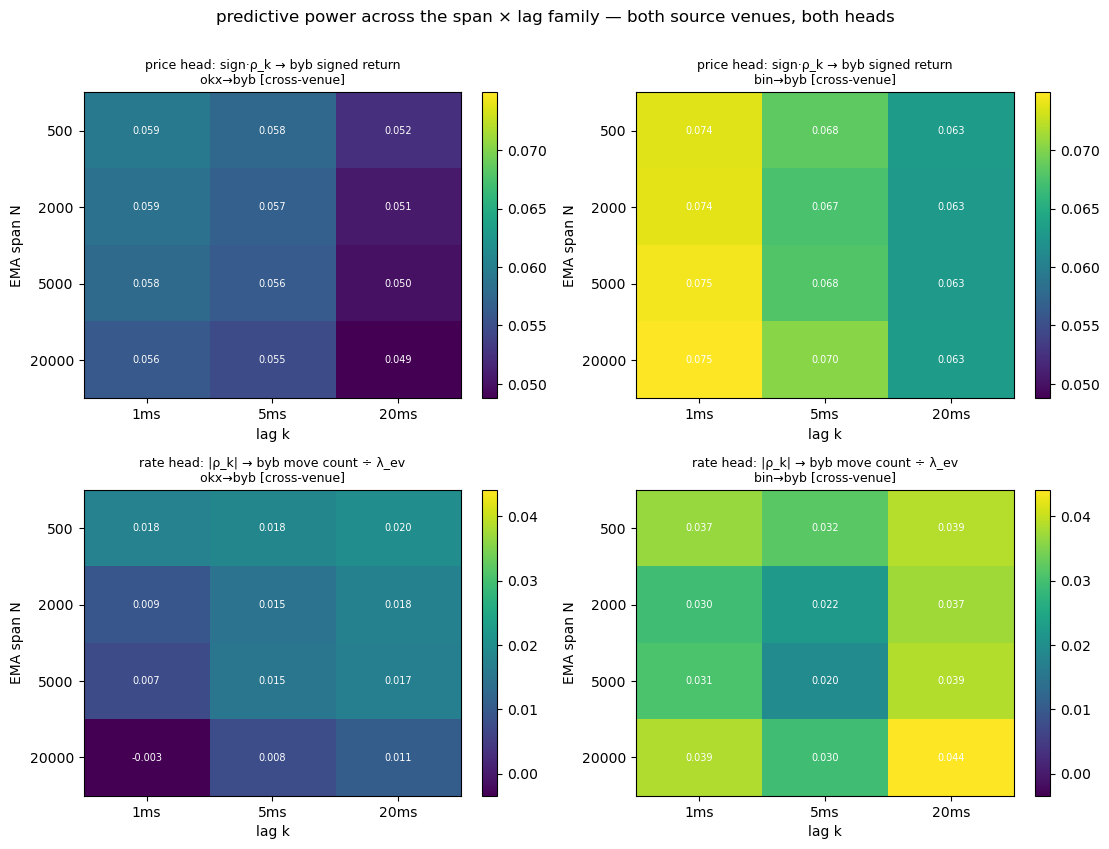

kept features (one per source venue, both fed to the model — none privileged; in-sample |IC| argmax, re-scored OOS below):
  okx:  price head (N=500, k=1ms) IC=+0.059   |  rate head (N=500, k=20ms) IC=+0.020
  bin:  price head (N=20000, k=1ms) IC=+0.075   |  rate head (N=20000, k=20ms) IC=+0.044


In [5]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by byb's λ_ev (the rate yardstick)
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer byb moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Sweep the FULL span × lag family, for BOTH source venues, BOTH heads. Standalone (uncontrolled) rank-IC — picks a cell.
# price_grid: signed feature sign·ρ_k -> byb signed return.   rate_grid: |ρ_k| (lead strength) -> byb move count ÷ λ_ev.
price_grid = {s: np.full((len(SPANS), len(LAGS_MS)), np.nan) for s in SOURCES}
rate_grid  = {s: np.full((len(SPANS), len(LAGS_MS)), np.nan) for s in SOURCES}
feat_cache = {}; rho_cache = {}
for s in SOURCES:
    for i, N in enumerate(SPANS):
        for j, k in enumerate(LAGS_MS):
            d = xv_leadlag(s, k, N); rk = rho(s, k, N); feat_cache[(s, N, k)] = d; rho_cache[(s, N, k)] = rk
            m = np.isfinite(d)
            price_grid[s][i, j] = spearmanr(d[m], target[m]).statistic
            mm = np.isfinite(rk)
            rate_grid[s][i, j]  = spearmanr(np.abs(rk[mm]), rate_target[mm]).statistic

fig, axes = plt.subplots(2, len(SOURCES), figsize=(5.6 * len(SOURCES), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: sign·ρ_k → byb signed return"),
                                     (rate_grid,  "rate head: |ρ_k| → byb move count ÷ λ_ev")]):
    allv = np.concatenate([grids[s].ravel() for s in SOURCES]); vmin, vmax = np.nanmin(allv), np.nanmax(allv)
    for col, s in enumerate(SOURCES):
        ax = axes[row][col]; grid = grids[s]; im = ax.imshow(grid, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(LAGS_MS))); ax.set_xticklabels([f"{k}ms" for k in LAGS_MS]); ax.set_xlabel("lag k")
        ax.set_yticks(range(len(SPANS))); ax.set_yticklabels(SPANS); ax.set_ylabel("EMA span N")
        ax.set_title(f"{head}\n{s}→byb [cross-venue]", fontsize=9)
        for i in range(len(SPANS)):
            for j in range(len(LAGS_MS)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the span × lag family — both source venues, both heads", y=1.005)
fig.tight_layout(); plt.show()

# We do NOT pick a venue (not "the best", not assumed). Both source legs are kept; the model weights whichever is
# leading. Choosing the best (span, lag) PER venue is fine; choosing a venue is not. NB: each grid cell is an
# IN-SAMPLE spearmanr and best_cell is the argmax|IC| over it (an in-sample maximisation) — used ONLY to PICK a
# (span, lag), never to claim OOS power. The chosen cells are re-scored OUT-OF-SAMPLE by the §6 walk-forward gates.
def best_cell(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {s: best_cell(price_grid[s]) for s in SOURCES}
rate_member  = {s: best_cell(rate_grid[s])  for s in SOURCES}
print("kept features (one per source venue, both fed to the model — none privileged; in-sample |IC| argmax, re-scored OOS below):")
for s in SOURCES:
    pi, pj = price_member[s]; ri, rj = rate_member[s]
    print(f"  {s}:  price head (N={SPANS[pi]}, k={LAGS_MS[pj]}ms) IC={price_grid[s][pi,pj]:+.3f}"
          f"   |  rate head (N={SPANS[ri]}, k={LAGS_MS[rj]}ms) IC={rate_grid[s][ri,rj]:+.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx: best alt (N=20000,k=5ms) IC|best +0.014;  OOS joint +0.054 vs solo +0.058 (Δ-0.003)  ->  one span suffices (no OOS gain)


  bin: best alt (N=500,k=1ms) IC|best +0.023;  OOS joint +0.068 vs solo +0.067 (Δ+0.001)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx: best alt (N=500,k=1ms) IC|best +0.011;  OOS joint +0.006 vs solo +0.012 (Δ-0.006)  ->  one span suffices (no OOS gain)


  bin: best alt (N=500,k=1ms) IC|best +0.029;  OOS joint +0.012 vs solo -0.028 (Δ+0.040)  ->  KEEP 2nd span (adds OOS)


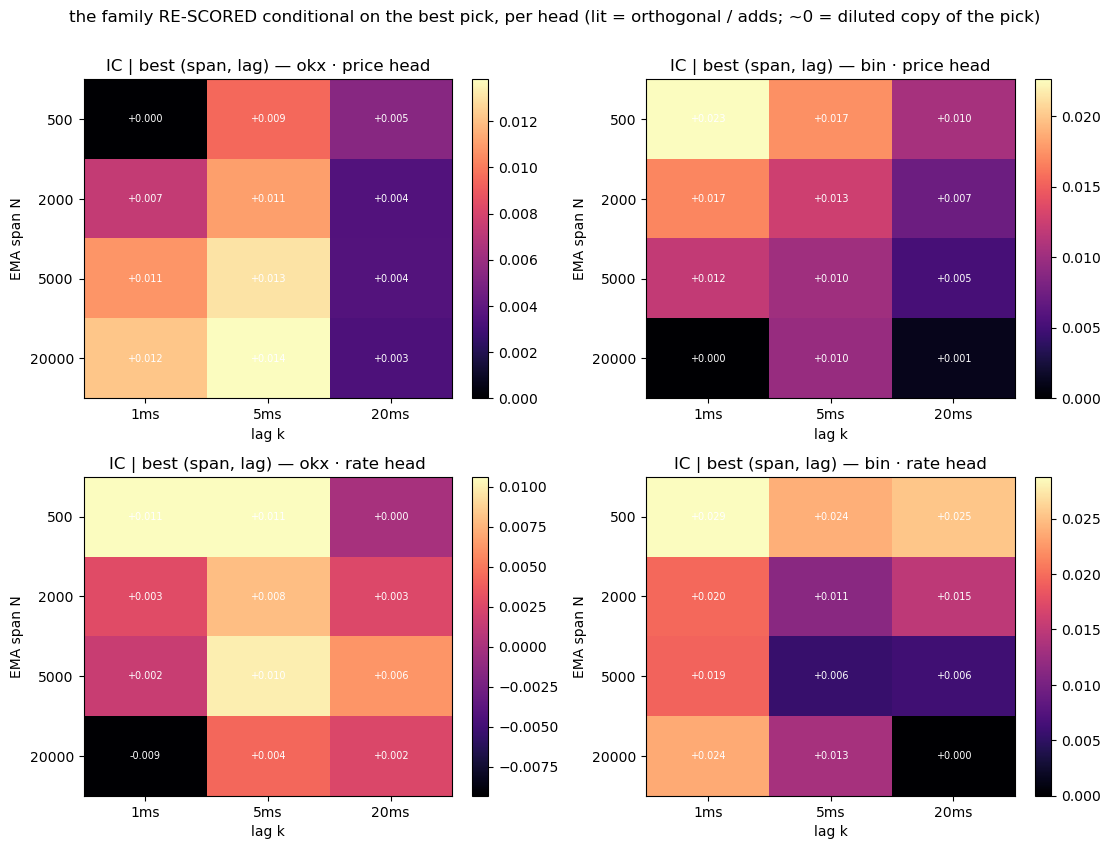

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the (span × lag) family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best (span, lag) per head by IC; now re-score the WHOLE family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the (span, lag) we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen cell, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a (venue, span, lag) cell to its scored feature, tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda ex, N, k: xv_leadlag(ex, k, N),         target,      price_member),
         ("rate head",  lambda ex, N, k: np.abs(rho(ex, k, N)),         rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(SOURCES), figsize=(5.6 * len(SOURCES), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(SOURCES):
        ci, cj = member[ex]; chosen = feat(ex, SPANS[ci], LAGS_MS[cj])
        cond = np.full((len(SPANS), len(LAGS_MS)), np.nan)
        for i, N in enumerate(SPANS):
            for j, k in enumerate(LAGS_MS):
                cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, N, k), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(LAGS_MS))); ax.set_xticklabels([f"{k}ms" for k in LAGS_MS]); ax.set_xlabel("lag k")
        ax.set_yticks(range(len(SPANS))); ax.set_yticklabels(SPANS); ax.set_ylabel("EMA span N")
        ax.set_title(f"IC | best (span, lag) — {ex} · {head}")
        for i in range(len(SPANS)):
            for j in range(len(LAGS_MS)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bi], LAGS_MS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (N={SPANS[bi]},k={LAGS_MS[bj]}ms) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best (span, lag) per head; a second cell is
only worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span × lag family
conditional on the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power
against the head's target **controlling for the cell we already picked** (the same partial-IC tool the echo-netting
cell uses; control = the chosen cell). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second cell only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed `sign·ρ_k` vs the σ-return target; rate → `|ρ_k|` vs the count
target). Read the per-venue verdicts above: **three** of the four legs — price okx (OOS Δ≈−0.003), price bin
(Δ≈+0.001), and rate okx (Δ≈−0.006) — show the best alternative collapsing to no OOS gain, so for those one
(span, lag) suffices on this block (a second time-scale is a diluted copy). The **fourth — rate-head bin** — is
the exception: the best alternative (N=500, k=1ms) is genuinely **orthogonal** (OOS joint **+0.012** vs solo
**−0.028**, Δ≈**+0.040**), so it **KEEPs** a second time-scale. That kept span is, however, **moot for shipping**:
the rate head as a whole **fails Gate B** downstream (§7 rate gate: joint marginal ≈ **−0.001**, positive in only
1/5 folds), so `|ρ_k|→count` carries no shippable signal on this block regardless of how many spans it uses. The
takeaway is therefore *one (span, lag) per head suffices — except rate bin, where a second time-scale adds OOS but
the head itself doesn't clear Gate B* — **not** a blanket "one per head suffices everywhere."

**Reading the heat-maps.** The **price head** (top) is where this feature lives: the signed `sign·ρ_k`
correlates with byb's next return — when the leading venue just moved, byb tends to follow — and the grid
picks out a best (span, lag) per venue. The **rate head** (bottom) is a weaker, diagnostic readout
(`|ρ_k| → byb move count`): a strongly coupled pair tends to accompany more catch-up moves, but direction is
the feature's real job. We keep **both** source venues and let the model weight whoever is leading; we only
choose the best (span, lag) per head per venue (in-sample — re-scored OOS by the gates below). The cell just
above already re-scored the family **conditional on that pick** (`partial-IC(cell | chosen)` + the
walk-forward joint-vs-solo verdict), so any genuinely orthogonal second time-scale per head is surfaced there.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the (span, lag) is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the cell pick. Held-out cell selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 4×3 span×lag grid of near-identical neighbours, so the
selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate
against), **never** a control. Fail any one of them = a level in disguise, not a feature. *(For a bounded
`[−1,1]` correlation like `ρ_k`, we expect scale steady and tracking near zero — but we measure, never assume:
a bounded quantity can still drift its working range across regimes.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `xv_leadlag`
is a cross-venue **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), both source venues together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular.)* **Mechanical-coupling
guard:** the gate scores the **σ_ev price target** (`fwd_return/σ_ev`) by default, but `xv_leadlag`'s `ρ_k`
divides by **no** yardstick at all — it shares no denominator with either target — so there is no spurious
ratio coupling to stratify away (`STRAT_VAR = None`). We still print the within-σ_ev stratified standalone IC
below as a *confirmation* that the unstratified IC isn't a σ_ev artefact.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the set of per-source-venue features — symmetric; KEEP BOTH venues. Marginal value is checked
# JOINTLY (do okx+bin together add over the controls?) and per-venue (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). xv_leadlag is an alpha, so all legs take the marginal branch.

disloc = {s: feat_cache[(s, SPANS[price_member[s][0]], LAGS_MS[price_member[s][1]])] for s in SOURCES}   # each venue at its best price-head cell
joint = signal_ic(list(disloc.values()), own=False)
strat = signal_ic_by_regime(list(disloc.values()), own=False)
pci = wf_marginal_ci(list(disloc.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = disloc[SOURCES[0]]                                # representative leg — for the momenta-overlap sanity print only (Gate A runs PER VENUE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER VENUE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="okx+bin together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{s}→byb alone — marginal over the controls (genuine: does {s} LEAD byb?)",
                   value=signal_ic([disloc[s]], own=False)) for s in SOURCES]
# σ_ev-coupling confirmation: xv_leadlag divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified standalone IC
# ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{s} — signed sign·ρ_k standalone IC, unstratified", value=round(ic(disloc[s], target), 3)) for s in SOURCES]
gate_rows += [dict(gate="B · coupling", detail=f"{s} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(disloc[s], target, sigma_at_anchor), 3)) for s in SOURCES]
for s in SOURCES:                                      # GATE A PER VENUE (worst coordinate per check) — bin AND okx, since the output distribution differs by venue
    a = gate_a(disloc[s])
    gate_rows += [dict(gate=f"A · regime-inv ({s})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({s})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({s})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({s})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.065  |  per-fold [0.066, 0.051, 0.058, 0.069, 0.079] (positive in 5/5)  |  block-bootstrap 90% CI [0.06, 0.068]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.009 vol 0.022  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""okx+bin together — marginal over the invariant controls""",0.065
"""B · signal""","""okx→byb alone — marginal over the controls (genuine: does okx LEAD byb…",0.052
"""B · signal""","""bin→byb alone — marginal over the controls (genuine: does bin LEAD byb…",0.064
"""B · coupling""","""okx — signed sign·ρ_k standalone IC, unstratified""",0.059
"""B · coupling""","""bin — signed sign·ρ_k standalone IC, unstratified""",0.075
"""B · coupling""","""okx — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",0.059
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",0.074
"""A · regime-inv (okx)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.15
"""A · regime-inv (okx)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.013


**Conclusion.** The price-head gate table is printed above; read its rows for this block. **Gate B** is the
marginal walk-forward rank-IC of the cross-venue `sign·ρ_k` legs over the regime-invariant controls — both
venues together (joint), and each on its own — with the per-fold spread and block-bootstrap 90% CI; the
`B · coupling` rows confirm the within-σ_ev stratified standalone IC barely moves from the unstratified one
(as expected, since `ρ_k` never divides by σ_ev). **Gate A** runs **per venue** (it is a distribution
property — bin is sub-ms fresh, okx stale): for a bounded `[−1,1]` correlation we expect scale ≪ 3 and the
mean/magnitude tracking under the ~0.05 / ~0.1 bars, and the printed rows say whether that holds on this
block. The **companion** reports the marginal within calm / mid / wild vol — read whether it stays positive
in all three. (`xv_leadlag` is inherently cross-venue, so neither leg is circular; the overlap-with-momenta
print confirms it really is an alpha, not a hidden regime descriptor.) The rate head is gated separately just
below — its verdict is read off the rate-head gate table, not inherited from these price-head gates.

**Now the rate head — its own gates, against the count target.** The block above gated the *price-cell*
feature against the σ_ev **price** target. The rate head is fed a **different-cell** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|ρ_k| → count` is the §6 diagnostic, and the model is
fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores `|feature|`**
— a *linear* score on the signed feature would read ≈ 0 precisely because the count relationship is
symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts. **Coupling guard:**
the price head used `STRAT_VAR=None` because `ρ_k` divides by no yardstick; the magnitude path has no sign
either, but `|ρ_k|` is still a bounded `[0,1]` correlation (no `1/λ_ev` factor) while `count/λ_ev ∝ 1/λ_ev`,
so they share no denominator — we add a within-λ_ev stratified line per venue to confirm the marginal isn't a
`1/λ_ev` artefact regardless. **Gate A** is re-run **per venue** on the rate-cell feature (a distribution
property — it differs by venue *and* by (span, lag)).

In [8]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-CELL feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-cell feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |ρ_k|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |ρ_k| is a bounded [0,1] correlation (no 1/λ_ev factor) while count/λ_ev ~ 1/λ_ev — no shared
#    denominator — but we add a within-λ_ev stratified line per venue to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER VENUE on the rate-cell feature (a distribution property — it differs by venue AND by (span, lag)).
disloc_rate = {s: rho_cache[(s, SPANS[rate_member[s][0]], LAGS_MS[rate_member[s][1]])] for s in SOURCES}   # ρ_k at each venue's rate-head cell
mag_rate    = {s: np.abs(disloc_rate[s]) for s in SOURCES}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |ρ_k|->count, marginal over the controls, both venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="okx+bin together — marginal |ρ_k|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{s}→byb alone — marginal |ρ_k|->count over the controls",
                   value=signal_ic([mag_rate[s]], own=False, tgt=rate_target)) for s in SOURCES]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{s} — |ρ_k|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[s], rate_target, lam_at_anchor), 3)) for s in SOURCES]
for s in SOURCES:
    a = gate_a(disloc_rate[s])
    rate_rows += [dict(gate=f"A · regime-inv ({s})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({s})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({s})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |ρ_k|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({s})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|ρ_k|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(80)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal -0.001  |  per-fold [-0.002, 0.002, -0.0, -0.001, -0.006] (positive in 1/5)  |  block-bootstrap 90% CI [-0.002, 0.0]  (block ~9409 anchors ~470.5s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""okx+bin together — marginal |ρ_k|->count over the controls; want >~ 0.01""",-0.001
"""B · signal (rate)""","""okx→byb alone — marginal |ρ_k|->count over the controls""",0.0
"""B · signal (rate)""","""bin→byb alone — marginal |ρ_k|->count over the controls""",-0.002
"""B · coupling (rate)""","""okx — |ρ_k|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)""",0.004
"""B · coupling (rate)""","""bin — |ρ_k|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)""",-0.002
"""A · regime-inv (okx)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.15
"""A · regime-inv (okx)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05""",0.128
"""A · regime-inv (okx)""","""|IC(|feature|, vol/rate level)| — the rate head sees |ρ_k|, worst coord; want < …",0.13
"""A · regime-inv (okx)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want <…",0.145


**Conclusion (rate head).** The rate-cell feature gets the same battery against the **count** target, both
venues — read the printed rows for this block. **Gate B** is the marginal `|ρ_k| → count` over the controls,
jointly and per venue, with the per-fold spread and CI; the `B · coupling (rate)` rows confirm the
within-λ_ev stratified IC stays positive (so the marginal isn't a `1/λ_ev` arithmetic artefact). **Gate A**
holds (or not) per venue on the rate-cell `ρ_k` — scale, signed mean-track, magnitude-track, dispersion,
each against the worst of the vol/rate coordinate. The **companion** reports the marginal within each
volatility regime. The rate head's verdict is read off *these* rows, not inherited from the price gates.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

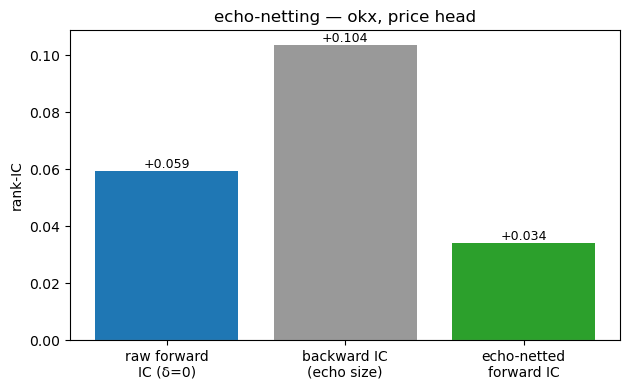

raw forward IC +0.059;  backward (echo) IC +0.104;  echo-netted forward IC +0.034  (the raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = SOURCES[0]                                     # one source venue to illustrate; every leg carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

pi, pj = price_member[rep_ex]; signed = xv_leadlag(rep_ex, LAGS_MS[pj], SPANS[pi])   # the chosen price-head feature (sign·ρ_k)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high signed-feature values — it should tilt one
  way as `sign·ρ_k` turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the **lead strength** `|ρ_k|` grows.

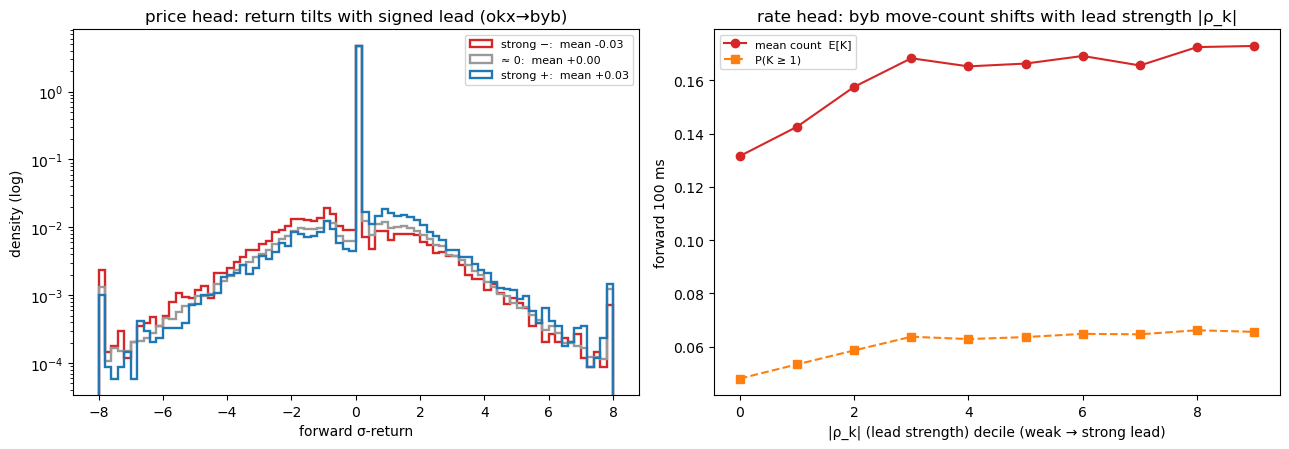

In [10]:
rep_s = SOURCES[0]                                                              # one source shown to illustrate; the model uses both
pi, pj = price_member[rep_s]; signed = xv_leadlag(rep_s, LAGS_MS[pj], SPANS[pi])
ri, rj = rate_member[rep_s];  strength = np.abs(rho(rep_s, LAGS_MS[rj], SPANS[ri]))
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-feature buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"), ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with signed lead ({rep_s}→byb)"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with lead strength |ρ_k|
dec = np.digitize(strength, np.nanpercentile(strength[np.isfinite(strength)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|ρ_k| (lead strength) decile (weak → strong lead)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: byb move-count shifts with lead strength |ρ_k|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads need — shown here
for one source venue (the model uses both). **Price head (left):** the forward-return distribution shifts
with the *signed* feature — read the group means in the legend (a negative mean when the leading venue just
moved down, positive when up, with the flat ≈0 group between) — so the sign carries direction, the feature's
main job. **Rate head (right):** the diagnostic readout of mean move-count `E[K]` and `P(K ≥ 1)` against the
`|ρ_k|` deciles — read whether it climbs with lead strength (more catch-up moves when the venues are strongly
coupled), the intensity-flavoured *diagnostic* the model would recover from the signed feature. But read this
panel as a within-block *picture*, not a verdict: the §6 rate-head gate table is the arbiter, and on this
block it does **not** support the rate head — its marginal `|ρ_k| → count` over the controls comes out ≈ 0 /
negative (joint −0.001, positive in only 1/5 folds; the calm/mid/wild companion negative in all three) and its
Gate A fails (track/dispersion well over bar on both venues). So the honest reading here is **one-sided**: the
**price head** clearly carries signal in the §1 direction (the signed return tilts with the lead), while the
rate head is at best a weak in-sample diagnostic that has **not** shown anything to learn beyond the controls
on this block — don't assert it has.

## 8. Input shaping for the network

This is a *different* step from §2. There we noted the feature needs no regime-division (it is a bounded
correlation). Here we reshape it for the neural network's input — roughly centred, unit-scale, no wild
outliers. `ρ_k ∈ [−1, 1]` and the signed feature `sign·ρ_k ∈ [−1, 1]` are bounded, but bounded ≠ tame: the
feature sits near zero most of the time (weakly-coupled venues), so a rare strong lead is many σ out and a
*plain* rescale leaves a heavy tail. We measure the kurtosis and the candidate transforms, and pick the
**lightest** one that actually pulls the tail in — read the printout, don't assume the boundedness suffices.

feature (sign·ρ_k): range [-0.594, +0.559]  std=0.064  skew=+0.01  excess_kurt=4.74  (0 = normal)
  z-score            excess_kurt=  4.74   max|·|=9.3
  robust + clip ±4   excess_kurt=  1.09   max|·|=4.0
  arcsinh(robust)    excess_kurt= -0.25   max|·|=3.3
  rank-Gaussian      excess_kurt= -0.00   max|·|=5.0


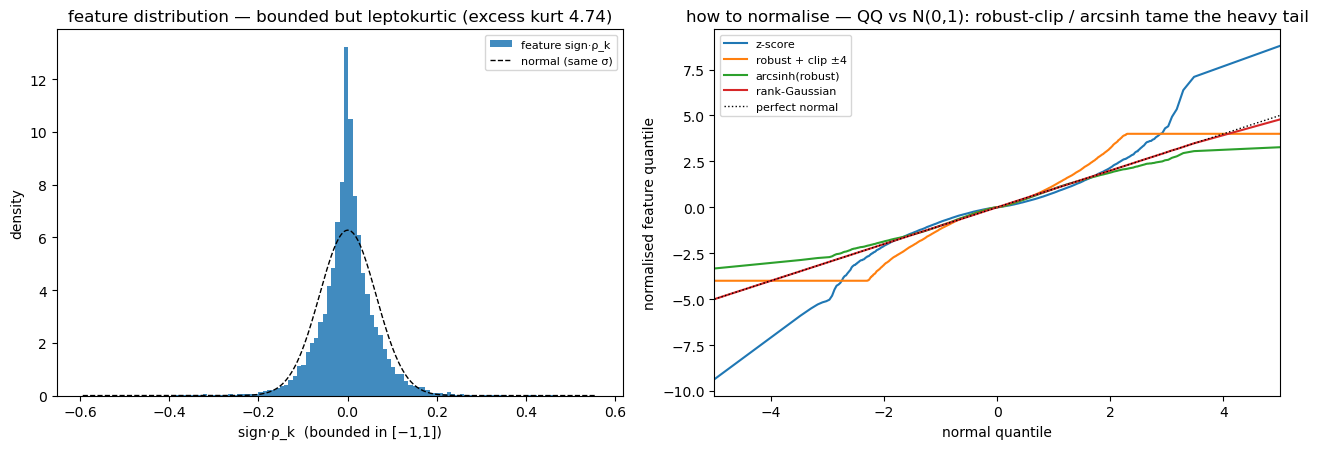

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_s = SOURCES[0]; pi, pj = price_member[rep_s]
f = xv_leadlag(rep_s, LAGS_MS[pj], SPANS[pi]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (sign·ρ_k): range [{f.min():+.3f}, {f.max():+.3f}]  std={f.std():.3f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.2f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature sign·ρ_k")
xg = np.linspace(f.min(), f.max(), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std() + 1e-12), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("sign·ρ_k  (bounded in [−1,1])"); axA.set_ylabel("density")
axA.set_title(f"feature distribution — bounded but leptokurtic (excess kurt {kurtosis(f):.2f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub2 = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub2], np.sort(v)[sub2], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): robust-clip / arcsinh tame the heavy tail"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it — and it argues *against* a bare z-score. The signed feature is
**bounded in `[−1, 1]`** by construction (a correlation times a sign) and **near-symmetric** (skew ≈ +0.01),
but bounded is **not** the same as tame: its working std is only ≈ 0.064 (the venues are weakly coupled most
of the time, so `sign·ρ_k` sits near zero), so the *rare* strong-lead reading near ±0.59 is ≈ 9 standard
deviations out. That shows up directly in the numbers: the **excess kurtosis is ≈ 4.74 — substantially
leptokurtic** (heavy-tailed at unit scale, not "low"/"mild"), and a **plain z-score leaves a `max|·| ≈ 9.3`
outlier** — exactly the kind of wild tail the boundedness alone does *not* tame. The printed rows show the
data prefers a heavier hand: **robust-z-then-clip ±4** drops the excess kurtosis to ≈ 1.09 with `max|·| = 4.0`,
and **arcsinh(robust)** to ≈ −0.25 with `max|·| = 3.3` — both pull the heavy tail in to roughly unit scale,
which the bare z-score does not. So the recommended shaping here is the **robust-z-then-clip (or arcsinh)**,
not the plain z-score: don't conflate `ρ_k`'s `[−1,1]` boundedness with a tame z-score — the small std blows
a 0.59 reading up to ≈ 9σ. (rank-Gaussian is the most aggressive, flattening to excess kurtosis ≈ 0 but at
`max|·| = 5.0`; reserve it if the leptokurtosis still hurts downstream.)

**Still to run** (same machinery): whether the feature adds over features we already have; whether the signal
is steady day-to-day; and whether it survives out-of-sample across a market-regime change. (The leak check
*inside* volatility buckets is no longer pending — Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

`xv_leadlag` is a quantity *between* a source venue and byb (okx→byb, bin→byb), so it has to be per-source —
there's no single "pooled" version (byb can't lead itself). But many features (trade-flow, order-flow
imbalance, queue imbalance) *can* be pooled into one number, and then you face a real choice: keep them
**per-exchange**, collapse to **one exchange**, or **pool** them all? The answer depends on the time-scale,
so sweep it and compare the three.

> **The table below is an illustrative example for a poolable trade-flow feature — it is NOT computed for
> `xv_leadlag`** (whose real per-source numbers are the heat-maps in §6, both legs kept, and the per-venue
> marginals in the §6 gate table). It just shows the typical pattern, predicting byb's next 100 ms. The
> time-scale column is labelled in ms / seconds only for readability — those wall-clock figures are just a
> translation of points on the trade-span N clock; the actual sweep is over trade-span N, as everywhere else.

| time-scale | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.22 | **0.23** | 0.22 | one exchange is enough — splitting just adds noise |
| ~500 ms | 0.11 | 0.12 | **0.16** | keep per-exchange — exchanges genuinely differ here |
| ≥ 2.5 s | 0.08 | 0.08 | 0.09 | exchanges agree — any one will do |

So: at the shortest scales the signal lives in one exchange; in a **middle band** the exchanges genuinely
differ (who's leading whom) and keeping them separate pays off; at long scales they all converge. In this
typical pattern pooling is rarely the best — it tends to blur the middle-band structure; that's why you
sweep and compare the three (per-exchange / single / pooled) rather than pool by default. (Longer prediction
horizons push the useful band wider, so in general sweep the horizon too.)

For `xv_leadlag` the analogous live question is whether keeping **both** source legs (okx→byb, bin→byb) is
worth it over a single one across the span × lag family — exactly what §6's per-venue heat-maps and the §6
gate table's per-venue marginals answer. We keep **both** legs as the safe default (no fixed leader); the data
says where each earns its keep. The cross-venue lead/lag is closed within milliseconds, so expect the venues
to genuinely differ at short span/lag (who is leading byb right now) and to converge at long span (the slow
drift is shared and one venue suffices).

## 10. The verdict, and what it takes to ship

**Disposition (read off this block's executed gates):** `xv_leadlag` is a correctly-built, parity-checked,
bounded **measurement of cross-venue lag-k co-movement** — the *construction* checks out (§4: the streaming
O(1) build reproduces every (source, lag) leg of the vectorized feature on a real block, at a mid span and the
largest shipped span, plus an independent blind `np.corrcoef` sign/magnitude spot-check). The atom is an
**uncentered** lagged cross-correlation `ρ_k ∈ [−1, 1]` (the cosine similarity of the two return streams, not
mean-centred Pearson — the gap is numerically tiny for near-zero-mean tick returns). Whether to **keep or
drop** it for the 100 ms target is decided by the §6 gate tables and the echo-netting section above — read
those printed numbers; the common finding at 100 ms is that the cross-venue legs carry a real but small forward
edge much of which is contemporaneous **echo** (backward IC ≳ forward IC → cite the **echo-netted** forward
IC), so this leans a parsimony call, while the construction and the lead itself check out.

- **Price head (direction, its natural head).** Feed the **signed** `sign·ρ_k` for **both** source venues at
  each venue's best (span, lag) cell (the §6 picks). A positive `ρ_k` says src moved a beat before byb; the
  sign carries which way. Gate B is the **marginal** rank-IC over the regime-invariant controls (printed in
  the §6 price gate table, with the per-fold spread and CI), Gate A is within bars per venue (or not — read
  the rows), and the companion reports whether the gain holds across calm / mid / wild vol. Cite the
  **echo-netted (partial) forward IC** from the echo-netting section for any echo-heavy leg (backward IC ≥
  forward IC) — that is the part of the edge *not* already underway, the honest forward number (recall a real
  cross-venue freshness lead is genuine edge here — production timing — not an artifact to coarsen away).
- **Rate head (intensity, diagnostic).** The same feature at its own rate-cell pick, scored as `|ρ_k| →
  count`; the model is fed the **signed** feature and recovers the magnitude itself, *and* learns how
  opposing leads cancel. Never feed a pre-computed `|ρ_k|` per venue. The rate-cell feature was put through
  its **own** Gate A/B battery against the **count** target (the rate-head gate table in §6) — its verdict is
  read off *those* rows, not inherited from the price gates.

Feed **every source venue's** signed feature in and let the model lean on whichever is leading; don't collapse
to one "leader." The feature needs **no** σ-division — it is a bounded `[−1, 1]` correlation already comparable
across regimes (the Gate A scale check confirms raw, measured not assumed). It is **per-source by
construction** — not poolable (§9); both legs are non-circular (other venues, never byb's own controls).

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version, **every (source, lag)
      leg** — §4 reproduces the vectorized feature on a real block at spans {2000, 20000} (well within the
      float32 ~1e-6 bar), including the bounded `k`-ms delay line for the lagged read, plus a blind
      `np.corrcoef` spot-check of `ρ_k`'s sign/magnitude
- [ ] the gate results recorded (with any failures justified) — price/rate Gate A/B + companion read off this
      block's printed tables
- [ ] the chosen heads and (span, lag) cells written down, with the yardstick spans (read from §6's picks)
- [ ] the echo-netted forward IC cited for any echo-heavy leg (backward IC ≥ forward IC), so the verdict cites the part of the edge not already underway
- [ ] multi-block OOS confirmation with the long embargo (this notebook is one block, one window); an
      OOS-standalone read and a shorter-horizon re-sweep (where the lead may not yet have propagated into byb's
      tape) are still TODO
- [x] the data quirks handled (bad zero-price prints filtered; the right price source per exchange — merged-mid
      for byb/okx, bin front_levels; same-timestamp prints collapsed to one trade-clock tick; the lagged src
      read served from a bounded wall-time delay line)